In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

project_root = Path(
        r"C:\Users\filax\OneDrive\Desktop\Code-repository\Data_science\telco_churn"
    )

dataset_dir = project_root / "telco_dataset"
telco_churn = pd.read_csv(dataset_dir / "Telco-Customer-Churn.csv")

In [2]:
import sqlite3
conn = sqlite3.connect(':memory:')
telco_churn.to_sql('customers', conn, index=False)

query_result_1 = pd.read_sql("""
    SELECT Contract, AVG(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churn_rate
    FROM customers
    GROUP BY Contract;
    """, con=conn)

query_result_2 = pd.read_sql("""
    SELECT InternetService, AVG(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churn_rate
    FROM customers
    GROUP BY InternetService;
    """, con=conn)

query_result_3 = pd.read_sql("""
    SELECT Churn, AVG(MonthlyCharges) AS avg_monthly_charges
    FROM customers
    GROUP BY Churn;
    """, con=conn)

query_result_4 = pd.read_sql("""
    SELECT PaymentMethod, AVG(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churn_rate
    FROM customers
    GROUP BY PaymentMethod;
    """, con=conn)

query_result_5 = pd.read_sql("""
    SELECT SeniorCitizen, AVG(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churn_rate
    FROM customers
    GROUP BY SeniorCitizen;
    """, con=conn)

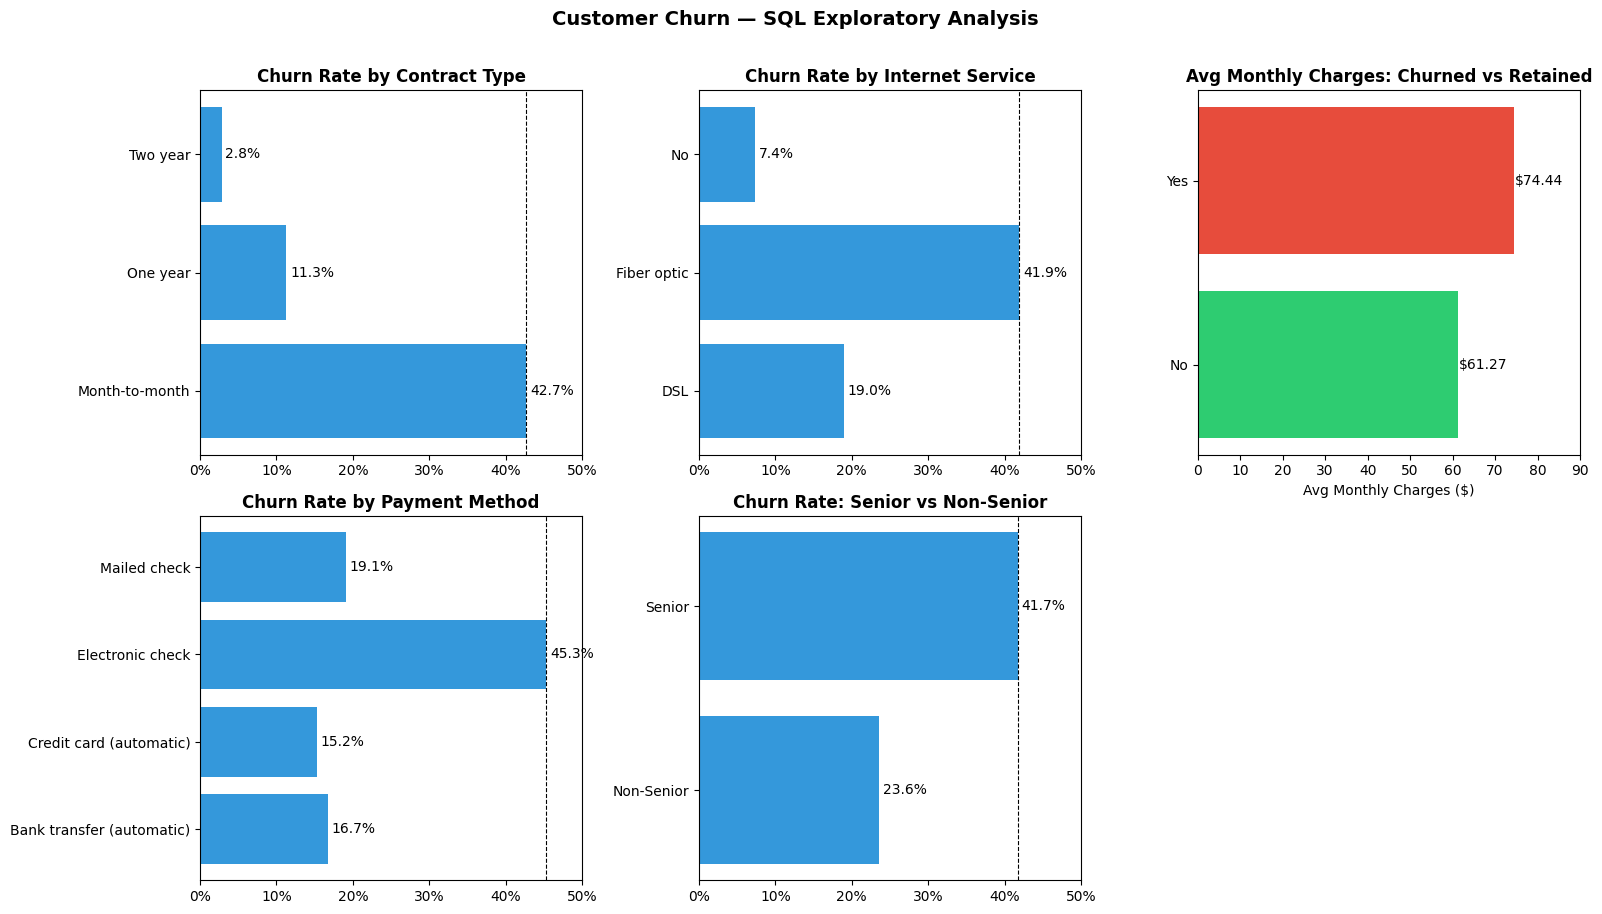

In [20]:
import os
import matplotlib.ticker as mticker
os.makedirs('outputs', exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
fig.suptitle('Customer Churn — SQL Exploratory Analysis', fontsize=14, fontweight='bold', y=1.01)

color_main = '#3498db'

# -- Plot 1: Churn rate by contract type --
ax = axes[0]
ax.barh(query_result_1['Contract'], query_result_1['churn_rate'], color=color_main)
ax.set_xlim(0.0, 0.50)
ax.set_title('Churn Rate by Contract Type', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.axvline(x=query_result_1['churn_rate'].max(), color='black', linestyle='--', linewidth=0.8)
for bar, val in zip(ax.patches, query_result_1['churn_rate']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=10)

# -- Plot 2: Churn rate by internet service --
ax = axes[1]
ax.barh(query_result_2['InternetService'], query_result_2['churn_rate'], color=color_main)
ax.set_xlim(0.0, 0.50)
ax.set_title('Churn Rate by Internet Service', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.axvline(x=query_result_2['churn_rate'].max(), color='black', linestyle='--', linewidth=0.8)
for bar, val in zip(ax.patches, query_result_2['churn_rate']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=10)

# -- Plot 3: Avg monthly charges by churn status --
ax = axes[2]
bar_colors = ['#e74c3c' if c == 'Yes' else '#2ecc71' for c in query_result_3['Churn']]
ax.set_xlim(0.0, 90.0)
ax.barh(query_result_3['Churn'], query_result_3['avg_monthly_charges'], color=bar_colors)
ax.set_title('Avg Monthly Charges: Churned vs Retained', fontweight='bold')
ax.set_xlabel('Avg Monthly Charges ($)')
for bar, val in zip(ax.patches, query_result_3['avg_monthly_charges']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'${val:.2f}', va='center', fontsize=10)

# -- Plot 4: Churn rate by payment method --
ax = axes[3]
ax.barh(query_result_4['PaymentMethod'], query_result_4['churn_rate'], color=color_main)
ax.set_xlim(0.0, 0.50)
ax.set_title('Churn Rate by Payment Method', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.axvline(x=query_result_4['churn_rate'].max(), color='black', linestyle='--', linewidth=0.8)
for bar, val in zip(ax.patches, query_result_4['churn_rate']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=10)

# -- Plot 5: Senior citizen churn rate --
ax = axes[4]
labels = ['Non-Senior', 'Senior']
ax.barh(labels, query_result_5['churn_rate'], color=color_main)
ax.set_xlim(0.0, 0.50)
ax.set_title('Churn Rate: Senior vs Non-Senior', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.axvline(x=query_result_5['churn_rate'].max(), color='black', linestyle='--', linewidth=0.8)
for bar, val in zip(ax.patches, query_result_5['churn_rate']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=10)

# -- Hide unused 6th subplot --
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/sql_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
telco_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
telco_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [23]:
telco_churn.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [24]:
telco_churn[telco_churn['TotalCharges'].str.strip() == '']['TotalCharges'].count()

np.int64(11)

In [25]:
telco_churn[telco_churn['TotalCharges'].str.strip() == ''][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


## gender showed no predictive signal — dropped from features

In [26]:
telco_churn.groupby('gender')['Churn'].apply(lambda x: (x == 'Yes').mean())

gender
Female    0.269209
Male      0.261603
Name: Churn, dtype: float64

In [27]:
telco_churn['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [28]:
telco_churn['TotalCharges'] = pd.to_numeric(telco_churn['TotalCharges'], errors='coerce')

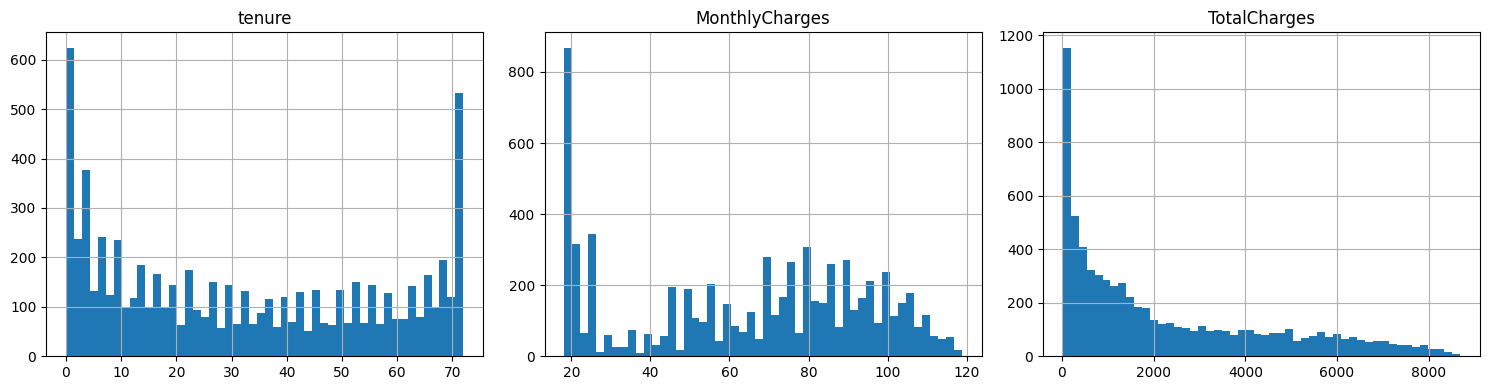

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    telco_churn[col].dropna().hist(bins=50, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig('outputs/numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
class TotalChargesImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self  # stateless, nothing to learn
    
    def transform(self, X, y=None):
        X = X.copy()  # never mutate the original
        mask = X['TotalCharges'].isna()
        X.loc[mask, 'TotalCharges'] = (
            X.loc[mask, 'tenure'] * X.loc[mask, 'MonthlyCharges']
        )
        return X

In [14]:
def map_binary(X):
    mapping = {'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0}
    return np.vectorize(mapping.get)(X)

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies', 'PaperlessBilling']
nominal_cols = ['InternetService', 'Contract', 'PaymentMethod']
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
passthrough_cols = ['SeniorCitizen']

preprocessor = ColumnTransformer(transformers=[
    ('binary', FunctionTransformer(map_binary), binary_cols),
    ('ohe', OneHotEncoder(drop='first'), nominal_cols),
    ('numerical', RobustScaler(), numerical_cols),
    ('passthrough', 'passthrough', passthrough_cols)
])

In [15]:
telco_churn['TotalCharges'] = pd.to_numeric(telco_churn['TotalCharges'], errors='coerce') # re-cast in case cell order changes

y = telco_churn['Churn'].map({'Yes': 1, 'No': 0})

X = telco_churn.drop(['Churn', 'gender', 'customerID'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = Pipeline(steps=[
    ('imputer', TotalChargesImputer()),
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier())
])

In [16]:
scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='roc_auc')

print(f"ROC-AUC: {scores.mean():.3f} (+/- {scores.std():.3f})")

ROC-AUC: 0.821 (+/- 0.010)


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

# ── Model registry ─────────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='logloss',   # suppresses XGBoost's own warning
        n_jobs=-1
    ),
    'SVC': SVC(
        probability=True,        # required for ROC-AUC scoring
        random_state=42
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        random_state=42
    ),
}

# ── Phase 1: cross-validated ROC-AUC, default hyperparameters ──────────────────
results = []

for name, model in models.items():
    pipeline.set_params(model=model)
    
    scores = cross_val_score(
        pipeline,
        X_train, y_train,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )
    
    results.append({
        'Model':    name,
        'Mean AUC': scores.mean().round(4),
        'Std AUC':  scores.std().round(4),
        'Min AUC':  scores.min().round(4),
        'Max AUC':  scores.max().round(4),
    })
    
    print(f"{name:<22} {scores.mean():.4f} ± {scores.std():.4f}")

# ── Summary table ───────────────────────────────────────────────────────────────
results_df = (
    pd.DataFrame(results)
      .sort_values('Mean AUC', ascending=False)
      .reset_index(drop=True)
)

print("\n── Phase 1 Summary ────────────────────────────────")
print(results_df.to_string(index=False))

Logistic Regression    0.8456 ± 0.0145
Decision Tree          0.6710 ± 0.0128
Random Forest          0.8219 ± 0.0103
XGBoost                0.8198 ± 0.0107
SVC                    0.8271 ± 0.0144
MLP                    0.7714 ± 0.0185

── Phase 1 Summary ────────────────────────────────
              Model  Mean AUC  Std AUC  Min AUC  Max AUC
Logistic Regression    0.8456   0.0145   0.8229   0.8642
                SVC    0.8271   0.0144   0.8088   0.8500
      Random Forest    0.8219   0.0103   0.8087   0.8391
            XGBoost    0.8198   0.0107   0.8045   0.8353
                MLP    0.7714   0.0185   0.7386   0.7891
      Decision Tree    0.6710   0.0128   0.6562   0.6869


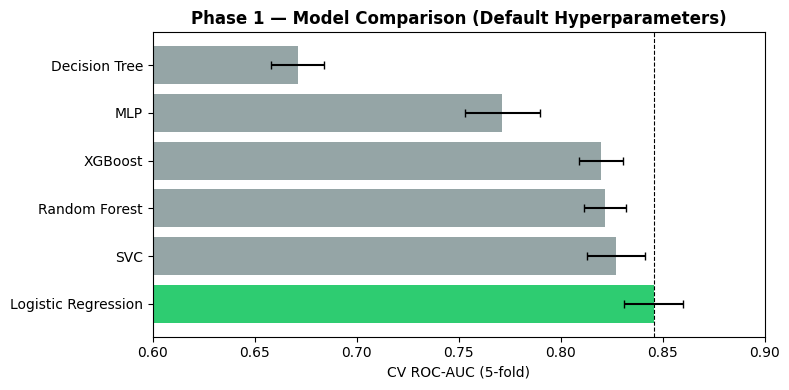

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71' if m == 'Logistic Regression' else '#95a5a6' 
          for m in results_df['Model']]
ax.barh(results_df['Model'], results_df['Mean AUC'], 
        xerr=results_df['Std AUC'], color=colors, capsize=3)
ax.set_xlim(0.60, 0.90)
ax.set_xlabel('CV ROC-AUC (5-fold)')
ax.set_title('Phase 1 — Model Comparison (Default Hyperparameters)', fontweight='bold')
ax.axvline(x=results_df['Mean AUC'].max(), color='black', linestyle='--', linewidth=0.8)
fig.tight_layout()
fig.savefig('outputs/phase1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
from sklearn.model_selection import GridSearchCV

# ── Logistic Regression ─────────────────────────────────────────────────────────
pipeline.set_params(model=LogisticRegression(max_iter=1000, random_state=42))

lr_param_grid = {
    'model__C':       [0.01, 0.1, 1.0, 10.0, 100.0],
    'model__penalty': ['l1', 'l2'],
    'model__solver':  ['saga'],   # saga supports both l1 and l2
}

lr_search = GridSearchCV(
    pipeline,
    param_grid=lr_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
)

print("Tuning Logistic Regression...")
lr_search.fit(X_train, y_train)

print(f"\nBest LR params:  {lr_search.best_params_}")
print(f"Best LR AUC:     {lr_search.best_score_:.4f}")

Tuning Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best LR params:  {'model__C': 10.0, 'model__penalty': 'l1', 'model__solver': 'saga'}
Best LR AUC:     0.8459


In [19]:
# ── XGBoost ─────────────────────────────────────────────────────────────────────
pipeline.set_params(model=XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
))

xgb_param_grid = {
    'model__n_estimators':  [100, 300, 500],
    'model__max_depth':     [3, 4, 6],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample':     [0.7, 1.0],
    'model__colsample_bytree': [0.7, 1.0],
    'model__reg_lambda':    [1.0, 5.0],   # L2 regularization
}

xgb_search = GridSearchCV(
    pipeline,
    param_grid=xgb_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
)

print("\nTuning XGBoost...")
xgb_search.fit(X_train, y_train)

print(f"\nBest XGB params: {xgb_search.best_params_}")
print(f"Best XGB AUC:    {xgb_search.best_score_:.4f}")


Tuning XGBoost...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best XGB params: {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 500, 'model__reg_lambda': 1.0, 'model__subsample': 0.7}
Best XGB AUC:    0.8480


── Phase 3: Test-Set ROC-AUC ───────────────────────────────
                        Model  Test AUC  Tuned
              XGBoost (tuned)    0.8438   True
Logistic Regression (default)    0.8407  False
  Logistic Regression (tuned)    0.8400   True
            XGBoost (default)    0.8262  False
                Random Forest    0.8256  False
                          SVC    0.8174  False
                          MLP    0.7797  False
                Decision Tree    0.6663  False

── Logistic Regression (tuned) ──
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


── XGBoost (tuned) ──
              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.83      1035
       Churn       0.5

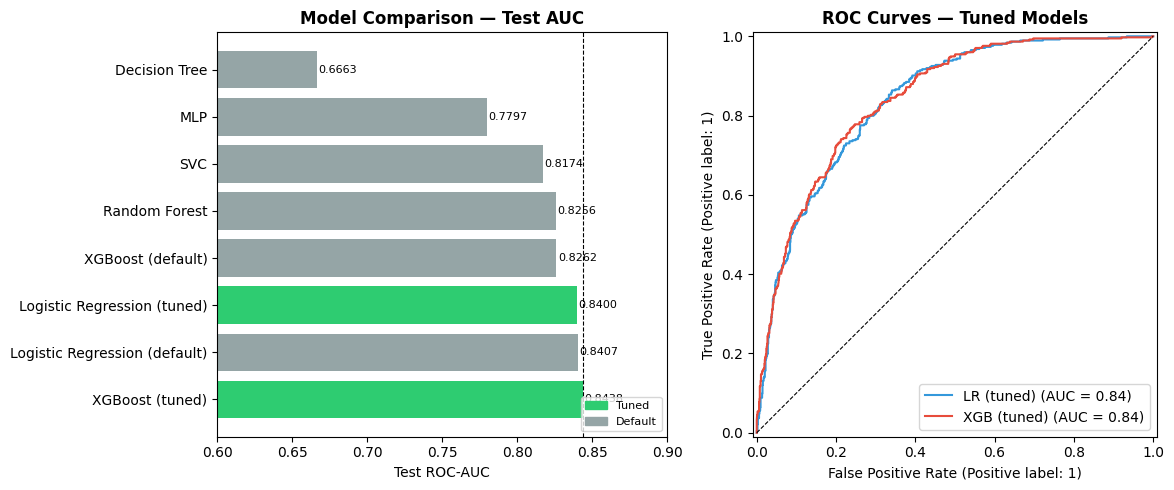

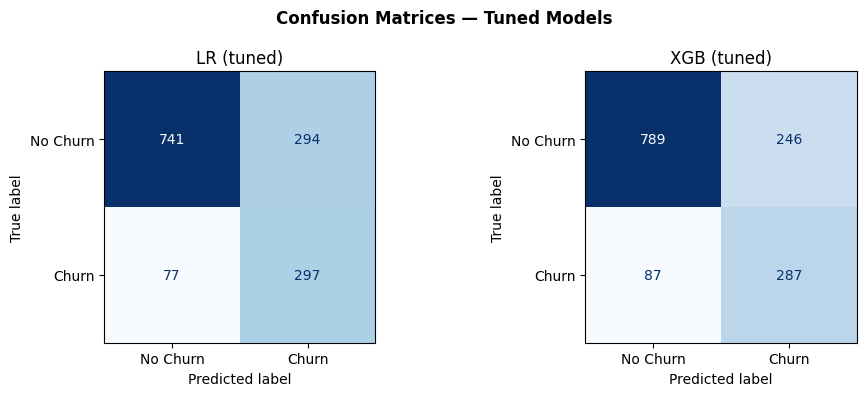

In [22]:
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    RocCurveDisplay,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.gridspec as gridspec

# ── 1. Collect all models for final evaluation ──────────────────────────────────
#    Tuned models come from search objects; others use default pipeline

phase1_models = {
    'Logistic Regression (default)': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':                  DecisionTreeClassifier(random_state=42),
    'Random Forest':                  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost (default)':              XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', n_jobs=-1),
    'SVC':                            SVC(probability=True, random_state=42),
    'MLP':                            MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
}

# Fit each Phase 1 model and collect test AUC
summary_rows = []

for name, model in phase1_models.items():
    pipeline.set_params(model=model)
    pipeline.fit(X_train, y_train)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    summary_rows.append({'Model': name, 'Test AUC': round(auc, 4), 'Tuned': False})

# Add tuned models (already fit on full X_train via refit=True)
for name, search in [('Logistic Regression (tuned)', lr_search),
                      ('XGBoost (tuned)',             xgb_search)]:
    y_prob = search.best_estimator_.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    summary_rows.append({'Model': name, 'Test AUC': round(auc, 4), 'Tuned': True})

summary_df = (
    pd.DataFrame(summary_rows)
      .sort_values('Test AUC', ascending=False)
      .reset_index(drop=True)
)

print("── Phase 3: Test-Set ROC-AUC ───────────────────────────────")
print(summary_df.to_string(index=False))


# ── 2. Classification report for the two tuned models ───────────────────────────
for name, search in [('Logistic Regression (tuned)', lr_search),
                      ('XGBoost (tuned)',             xgb_search)]:
    y_pred = search.best_estimator_.predict(X_test)
    print(f"\n── {name} ──")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


# ── 3. Visualization ─────────────────────────────────────────────────────────────
import os
os.makedirs('outputs', exist_ok=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# -- 3a. AUC bar chart --
colors = ['#2ecc71' if t else '#95a5a6' for t in summary_df['Tuned']]
bars = ax1.barh(summary_df['Model'], summary_df['Test AUC'], color=colors)
ax1.set_xlim(0.60, 0.90)
ax1.set_xlabel('Test ROC-AUC')
ax1.set_title('Model Comparison — Test AUC', fontweight='bold')
ax1.axvline(x=summary_df['Test AUC'].max(), color='black', linestyle='--', linewidth=0.8)
for bar, val in zip(bars, summary_df['Test AUC']):
    ax1.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8)
from matplotlib.patches import Patch
ax1.legend(handles=[Patch(color='#2ecc71', label='Tuned'),
                    Patch(color='#95a5a6', label='Default')],
           loc='lower right', fontsize=8)

# -- 3b. ROC curves (tuned models only) --
for name, search, color in [('LR (tuned)',  lr_search,  '#3498db'),
                              ('XGB (tuned)', xgb_search, '#e74c3c')]:
    RocCurveDisplay.from_estimator(
        search.best_estimator_, X_test, y_test,
        name=name, color=color, ax=ax2
    )
ax2.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax2.set_title('ROC Curves — Tuned Models', fontweight='bold')

fig.tight_layout()
fig.savefig('outputs/phase3_results.png', dpi=150, bbox_inches='tight')
plt.show()

# -- 3c. Confusion matrices --
fig2, axes = plt.subplots(1, 2, figsize=(10, 4))
fig2.suptitle('Confusion Matrices — Tuned Models', fontweight='bold')

for ax, (name, search) in zip(axes, [('LR (tuned)',  lr_search),
                                       ('XGB (tuned)', xgb_search)]):
    y_pred = search.best_estimator_.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

fig2.tight_layout()
fig2.savefig('outputs/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()